# 🧪Lab: Predicting Seismic Building Response with Support Vector Regression

In this lab, you will practice **Support Vector Machine (SVM)** in the context of **regression**. Over the past two weeks, we have focused on SVM for **classification problems**. However, SVM can also be extended to handle **regression tasks**—this is known as **Support Vector Regression (SVR)**.

To explore this, you will work with the following paper:  https://www.nature.com/articles/s41598-024-81705-3

In this paper, the authors use **real seismic monitoring data** to develop an SVR-based model for predicting the **maximum inter-story drift ratio** of buildings during earthquakes. The authors compare a full-feature model with a reduced-feature version, and demonstrate that SVR is effective in this complex, real-world regression setting.

You will begin by reading the **introduction** of the paper to understand the motivation behind the problem. Later, you will apply Support Vector Regression to their dataset.

Reference:

- Tao, D., Fang, S., Liu, H. et al. Support vector regression model for the prediction of buildings’ maximum seismic response based on real monitoring data. Sci Rep 14, 29874 (2024). https://doi.org/10.1038/s41598-024-81705-3

--- 

**Software**: Use `scikit-learn` and its implementation of Support Vector Regression in this lab. https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html

---

**Collaboration Note**: This assignment is designed to support collaborative work. We encourage you to divide tasks among group members so that everyone can contribute meaningfully. Many components of the assignment can be approached in parallel or split logically across team members. Good coordination and thoughtful integration of your work will lead to a stronger final result.

--- 

In total, this lab assignment will be worth **100 points**.

--- 
**Submission notes**:

* Write down all group members' names, or at least the group name (if you have one and you previously provided it), in the first cell of the notebook.

* Verify that the notebook runs as expected and that all required outputs are included.


In [1]:
names = "Paco, Saejin, David"

## 1. Paper reflection (10 points)

a. After reading the introduction of the paper, discuss within the group and address the following questions:
   
   - Why is predicting seismic building response important? (You may consider implications for human safety, economic losses, emergency planning, etc)

- Why might the dataset of this study be particularly well-suited for a machine learning approach? (You may think about the volume and diversity of data, the types of features provided, and the limitations of traditional physics-based methods).

Please, elaborate on your answers.

YOUR TEXT HERE

b. After reading the paper, explain, in your own words, how Support Vector Regression (SVR) works. In addition, explain Formulas (1) to (11) from the paper, specifically, what is the intuition behind each equation in light of what we covered in class regarding Support Vector Machine, so you can see the correspondence between SVM for classification and regression.

# Just some clarification from Claude to help:
If a point's error is strictly inside the tube ($|f(x_i) - y_i| < \epsilon$): loss = 0. The constraint $f(x_i) - y_i \le \epsilon + \xi_i$ has slack (room to spare) — it's not "tight." By complementary slackness, this forces $\alpha_i = 0$ (and similarly $\beta_i = 0$). Not a support vector.

If a point's error is exactly at the boundary ($|f(x_i) - y_i| = \epsilon$): the constraint is tight but $\xi_i = 0$ (no slack needed). This is the boundary case — $\alpha_i$ can be nonzero here.

If a point's error is outside the tube ($|f(x_i) - y_i| > \epsilon$): the point violates the tube, slack $\xi_i > 0$ is required to satisfy the constraint, loss is nonzero (eq. 3), and $\alpha_i$ (or $\beta_i$) must be nonzero to enforce that constraint in the optimization. This is a support vector.

What the slack variable literally represents

Recall the constraint from eq. (5):

$$f(x_i) - y_i \le \epsilon + \xi_i, \qquad \xi_i \ge 0$$

Rearrange this:

$$\xi_i \ge f(x_i) - y_i - \epsilon$$

So $\xi_i$ is essentially a **buffer/cushion amount** that gets added on top of $\epsilon$ to still make the inequality hold true, even when the raw prediction error is bigger than $\epsilon$.

Two cases

**Case 1: point is inside the tube** ($f(x_i) - y_i \le \epsilon$)
The inequality $f(x_i) - y_i \le \epsilon + \xi_i$ is already satisfied even with $\xi_i = 0$. No extra slack needed. So the optimizer sets $\xi_i = 0$ (since $C\xi_i$ is being minimized in eq. 4, it won't add slack unless forced to).

**Case 2: point is outside the tube** ($f(x_i) - y_i > \epsilon$)
Now $\epsilon$ alone isn't enough to satisfy the inequality — the raw error exceeds it. So $\xi_i$ has to soak up the *excess* amount:

$$\xi_i = f(x_i) - y_i - \epsilon > 0$$

This is literally the same quantity as $E_i$ in eq. (3) — the slack variable **is** the amount by which the point violates the tube, once you're outside it.

Concrete numeric example

Say $\epsilon = 0.05$ and for some point, the model's prediction error is $f(x_i) - y_i = 0.20$.

- Is $0.20 \le 0.05$? No — the raw error already exceeds the tube.
- So we need $\xi_i$ such that $0.20 \le 0.05 + \xi_i$, i.e., $\xi_i \ge 0.15$.
- The optimizer will set $\xi_i = 0.15$ exactly (no more than needed, since eq. 4 penalizes $\xi_i$ directly via $C\xi_i$).

So $\xi_i = 0.15 > 0$: a **positive slack** value, representing "how far past the tolerance boundary this point actually is."

Why this matters for support vectors

Because $\xi_i > 0$ only when the point is genuinely outside the tube, this is exactly the case where the constraint $f(x_i)-y_i \le \epsilon+\xi_i$ is **active/tight** (holds with equality, not slack in the everyday-English sense of "room to spare" — confusingly, "slack variable" is the technical term for the buffer, even though when it's positive there's actually *no* spare room left in the original ε-only constraint). That tightness is what forces the associated Lagrange multiplier $\alpha_i$ to be nonzero via complementary slackness — making that point a support vector.

So: $\xi_i = 0$ → point fits within $\epsilon$ → not a support vector (usually).
$\xi_i > 0$ → point needed "extra room" beyond $\epsilon$ to be accommodated → it's a boundary-violating point → support vector.

A support vector is a training data point whose prediction error is large enough that it sits on the boundary of, or outside, the ε-insensitive tube — meaning the model's prediction for that point is not comfortably within the acceptable tolerance $\epsilon$ of the true value.

## Equation 1
Equation 1 states that given a linear regression function defined over a feature-space transformation $\phi$, all training samples can be fitted such that the prediction error stays within a permissible tolerance, $\epsilon$.

## Equation 2
Equation 2 is the optimization function that is to be minimized with two terms: the total error (the sum of errors), and the regularization term (weighted combination of individual parameters) that penalizes large weights. $\lambda$ is a penalty parameter that controls how heavily large weights are penallized relative to fitting error (controls overfitting).

## Equation 3
Equation 3 defines how error is classified. Error is 0 if the calculated error is within the tube ($\le$ $\epsilon$), or is simply the raw error directly otherwise.

## Equation 4 & 5 
Equations 4 and 5 reformulat the optimization function from Equation 2 by introducing $\xi_i$ (predictions that are too high) and $\xi_i^*$ (for predictions that are too low), which are slack variables that allow for controlled violations of the tube. C then sets the degree of how these violations are penalized. A large C forces the model to work harder to avoid slack, whereas a small C will favor a simpler function/more violations (similar to $\lambda$)

## Equation 6
Equation 6 converts the problem from a constrained optimization problem (that is, an optimization function with constraitc e.g., $\xi_i^*$ can't be negative, etc.) into an unconstrained one (that is, simply minimizing and maximizing a function over all possible values of variables with no constraints). This is done by attaching Lagrange multipliers to each constraint/term. The resulting Lagrangian equation is solved by minimizing over the original variables. Setting the derivative of this Lagrangian with respect to the original parameters to zero will result with the conditions that respresent the optimal solution.

## Equations 7, 8, & 9
These equations set the derivatives of $L$ from Equation 6 with respect to $W$, $b$, $\xi_i$, $\xi_i^*$ to zero, which produces:

7. The optimal W, which is a linear combination of the transformed training inputs ( $\Phi(x_i)$ ) and the weight $(\alpha_i-\beta_i)$. Points where this weight are zero contribe nothing to the model, and only points with a nonzero $(\alpha_i-\beta_i)$ (that is, points on/outside the tube boundary) matter. Those are the support vectors
8. Equation 8 is a balance condition for the Lagrange multipliers, rooting from $\partial L/\partial b = 0$. It requires the "overshoot" multipliers ($\alpha_i$) and "undershoot" multipliers ($\beta_i$) to sum to a net zero across all training points. This offsetting is what keeps the model's bias term $b$ well-defined.
9. Ties the Lagrangian multipliers back to constraint C, implying that $0\le\alpha_i,\beta_i\le C$, determining how much influence any single point can have.

## Equation 10
Equation 10 solves for the intercept $b$ using a support vector $x_j$ sitting exactly on the boundary of the $\epsilon$-tube, meaning its prediction satisfies $f(x_j) - y_j = \epsilon$ (since it's right at the edge). Substituting $f(x_j) = W^T\Phi(x_j) + b$ into this and rearranging gives $b = y_j - W^T\Phi(x_j) + \epsilon$. Substituting $W$ from equation 7 into this gives:

$b = y_j - \sum_{i=1}^n(\alpha_i-\beta_i)\,\Phi(x_i)^T\Phi(x_j) + \epsilon$

The term $\Phi(x_i)^T\Phi(x_j)$ is the dot product between two transformed points, and can be replaced by the kernel function $k(x_i,x_j) = \Phi^T(x_i)\Phi(x_j)$, which avoids ever having to compute $\Phi$ explicitly. This gives the final form of equation 10:

$b = y_j - \sum_{i=1}^n(\alpha_i-\beta_i)\,k(x_i,x_j) + \epsilon$

## Equation 11
Equation 11 is the final trained SVR model that predicts a new point $x_j$'s output as a kernel-weighted sum over the support vectors, plus the bias $b$. It comes from substituting $W$ (eq. 7) into $f(x)=W^T\Phi(x)+b$ and replacing the inner product with the kernel $k(x_i,x_j)$, as in eq. (10). Since non-support-vectors have $(\alpha_i-\beta_i)=0$, only support vectors actually contribute to the prediction.

## 2. Exploratory Analysis (15 Points)

a. Load the dataset accompanying this lab and create a new dataset containing the same input features used as predictors in the paper, along with the target variable, *Drift*. **You will use only this new dataset throughout the remainder of the lab.** Display the first few rows of the resulting dataset.

*Hint*: The exact input features used in the predictive framework are clearly specified in the paper. You may also refer to Table 3 to help identify the corresponding features in the provided dataset.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge

In [3]:
# Load the dataset
data = pd.read_excel("data_lab02.xlsx", header=None)
df = data.copy() # just to keep raw data
df.head() # need this to find the column indexes for the selected features
df = df.iloc[3:].reset_index(drop=True) # getting rid of first three columns

y = df.iloc[:, 26]
X = df.drop(columns=26)

# column indexes to get rid of, based on the paper:
cols_to_drop = [0, 1, 4, 5, 8, 9, 27, 28, 29]
# getting rid of network, building id, soil type, vs30, typology, event date,
# PTA, PTV, PTD

X_SVR = X.drop(columns=df.columns[cols_to_drop])

columns = [ # as ordered in the dataset
    # Building Information (4)
    "B_LAT", "B_LONG", "H", "N", 

    # Events Information (4)
    "E_LAT", "E_LONG", "M", "DEP", 
    
    # Ordinate Intensity Measures (6)
    "PGA", "PGV", "PGD", "IA", "DP", "CAV",
    
    # Spectrum Intensity Measures (9)
    "SA1", "SV1", "SD1", "SA2", "SV2", "SD2", 

    # Building Frequency Information (2)
    "F1", "F2",
    
    # Average Spectrum Intensity Measures (3)
    "AVG_SA", "AVG_SV", "AVG_SD",
    
    # Duration of Strong Motion (16)
    "DE","DB1", "DU1", "DB2", "DU2", "DB3", "DU3", "DB4", "DU4", 
    "DSA1", "DSA2", "DSV1", "DSV2", "DSD1", "DSD2","DZX" 
]

X_SVR.columns = columns

# deleting rows with missing values
X_SVR = X_SVR.dropna()
y = y[X_SVR.index]

# first few rows
X_SVR.shape # should show around 12k rows with dropped data
X_SVR.head()

,B_LAT,B_LONG,H,N,E_LAT,E_LONG,M,DEP,PGA,PGV,...,DU3,DB4,DU4,DSA1,DSA2,DSV1,DSV2,DSD1,DSD2,DZX
0,36.132,140.073,3400,8,34.03,136.2283,5.3,420.7,1.577005,0.073452,...,0,0,0,54.89,73.15,56.97,81.65,93.23,122.2,54.300537
1,36.132,140.073,3400,8,36.1067,139.8917,3.8,16.6,3.449968,0.132411,...,0,0,0,5.96,19.57,13.88,27.74,25.26,63.18,6.934593
2,36.132,140.073,3400,8,37.02,141.0583,4.2,132.2,0.854165,0.036735,...,0,0,0,10.6,29.11,18.58,48.81,70.65,72.53,5.923775
3,36.132,140.073,3400,8,36.045,140.0867,3.4,9.8,0.549761,0.026009,...,0,0,0,10.45,25.24,13.61,32.37,33.76,57.79,5.139623
4,36.132,140.073,3400,8,35.46,140.7517,5.7,96.6,5.863478,1.006804,...,0,0,0,24.25,48.01,23.06,50.12,28.47,70.65,20.686939


In [4]:
print(X_SVR.info()) # check for missing values and data types
# they're all objects so we need to convert them to float
X_SVR = X_SVR.astype(float)


<class 'pandas.DataFrame'>
Index: 11916 entries, 0 to 12502
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   B_LAT   11916 non-null  object
 1   B_LONG  11916 non-null  object
 2   H       11916 non-null  object
 3   N       11916 non-null  object
 4   E_LAT   11916 non-null  object
 5   E_LONG  11916 non-null  object
 6   M       11916 non-null  object
 7   DEP     11916 non-null  object
 8   PGA     11916 non-null  object
 9   PGV     11916 non-null  object
 10  PGD     11916 non-null  object
 11  IA      11916 non-null  object
 12  DP      11916 non-null  object
 13  CAV     11916 non-null  object
 14  SA1     11916 non-null  object
 15  SV1     11916 non-null  object
 16  SD1     11916 non-null  object
 17  SA2     11916 non-null  object
 18  SV2     11916 non-null  object
 19  SD2     11916 non-null  object
 20  F1      11916 non-null  object
 21  F2      11916 non-null  object
 22  AVG_SA  11916 non-null  object
 23  AV

In [5]:
print(X_SVR.info()) # checking again to ensure conversion was successful

<class 'pandas.DataFrame'>
Index: 11916 entries, 0 to 12502
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   B_LAT   11916 non-null  float64
 1   B_LONG  11916 non-null  float64
 2   H       11916 non-null  float64
 3   N       11916 non-null  float64
 4   E_LAT   11916 non-null  float64
 5   E_LONG  11916 non-null  float64
 6   M       11916 non-null  float64
 7   DEP     11916 non-null  float64
 8   PGA     11916 non-null  float64
 9   PGV     11916 non-null  float64
 10  PGD     11916 non-null  float64
 11  IA      11916 non-null  float64
 12  DP      11916 non-null  float64
 13  CAV     11916 non-null  float64
 14  SA1     11916 non-null  float64
 15  SV1     11916 non-null  float64
 16  SD1     11916 non-null  float64
 17  SA2     11916 non-null  float64
 18  SV2     11916 non-null  float64
 19  SD2     11916 non-null  float64
 20  F1      11916 non-null  float64
 21  F2      11916 non-null  float64
 22  AVG_SA  11916 

In [6]:
X_SVR.head() # check the first few rows to just to confirm data looks correct

,B_LAT,B_LONG,H,N,E_LAT,E_LONG,M,DEP,PGA,PGV,...,DU3,DB4,DU4,DSA1,DSA2,DSV1,DSV2,DSD1,DSD2,DZX
0,36.132,140.073,3400.0,8.0,34.0300,136.2283,5.3,420.7,1.577005,0.073452,...,0.0,0.0,0.0,54.89,73.15,56.97,81.65,93.23,122.20,54.300537
1,36.132,140.073,3400.0,8.0,36.1067,139.8917,3.8,16.6,3.449968,0.132411,...,0.0,0.0,0.0,5.96,19.57,13.88,27.74,25.26,63.18,6.934593
2,36.132,140.073,3400.0,8.0,37.0200,141.0583,4.2,132.2,0.854165,0.036735,...,0.0,0.0,0.0,10.60,29.11,18.58,48.81,70.65,72.53,5.923775
3,36.132,140.073,3400.0,8.0,36.0450,140.0867,3.4,9.8,0.549761,0.026009,...,0.0,0.0,0.0,10.45,25.24,13.61,32.37,33.76,57.79,5.139623
4,36.132,140.073,3400.0,8.0,35.4600,140.7517,5.7,96.6,5.863478,1.006804,...,0.0,0.0,0.0,24.25,48.01,23.06,50.12,28.47,70.65,20.686939


b. Explore the distribution of the target variable (Drift), and create scatterplots between Drift and input features.

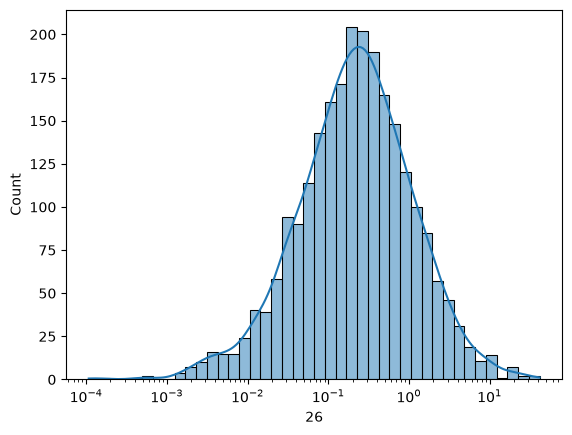

In [7]:
# explore distribution of the target variable
sns.histplot(y, kde=True, log_scale=True) # need to log scale
plt.show()
# using log scale b/c that's what the paper did

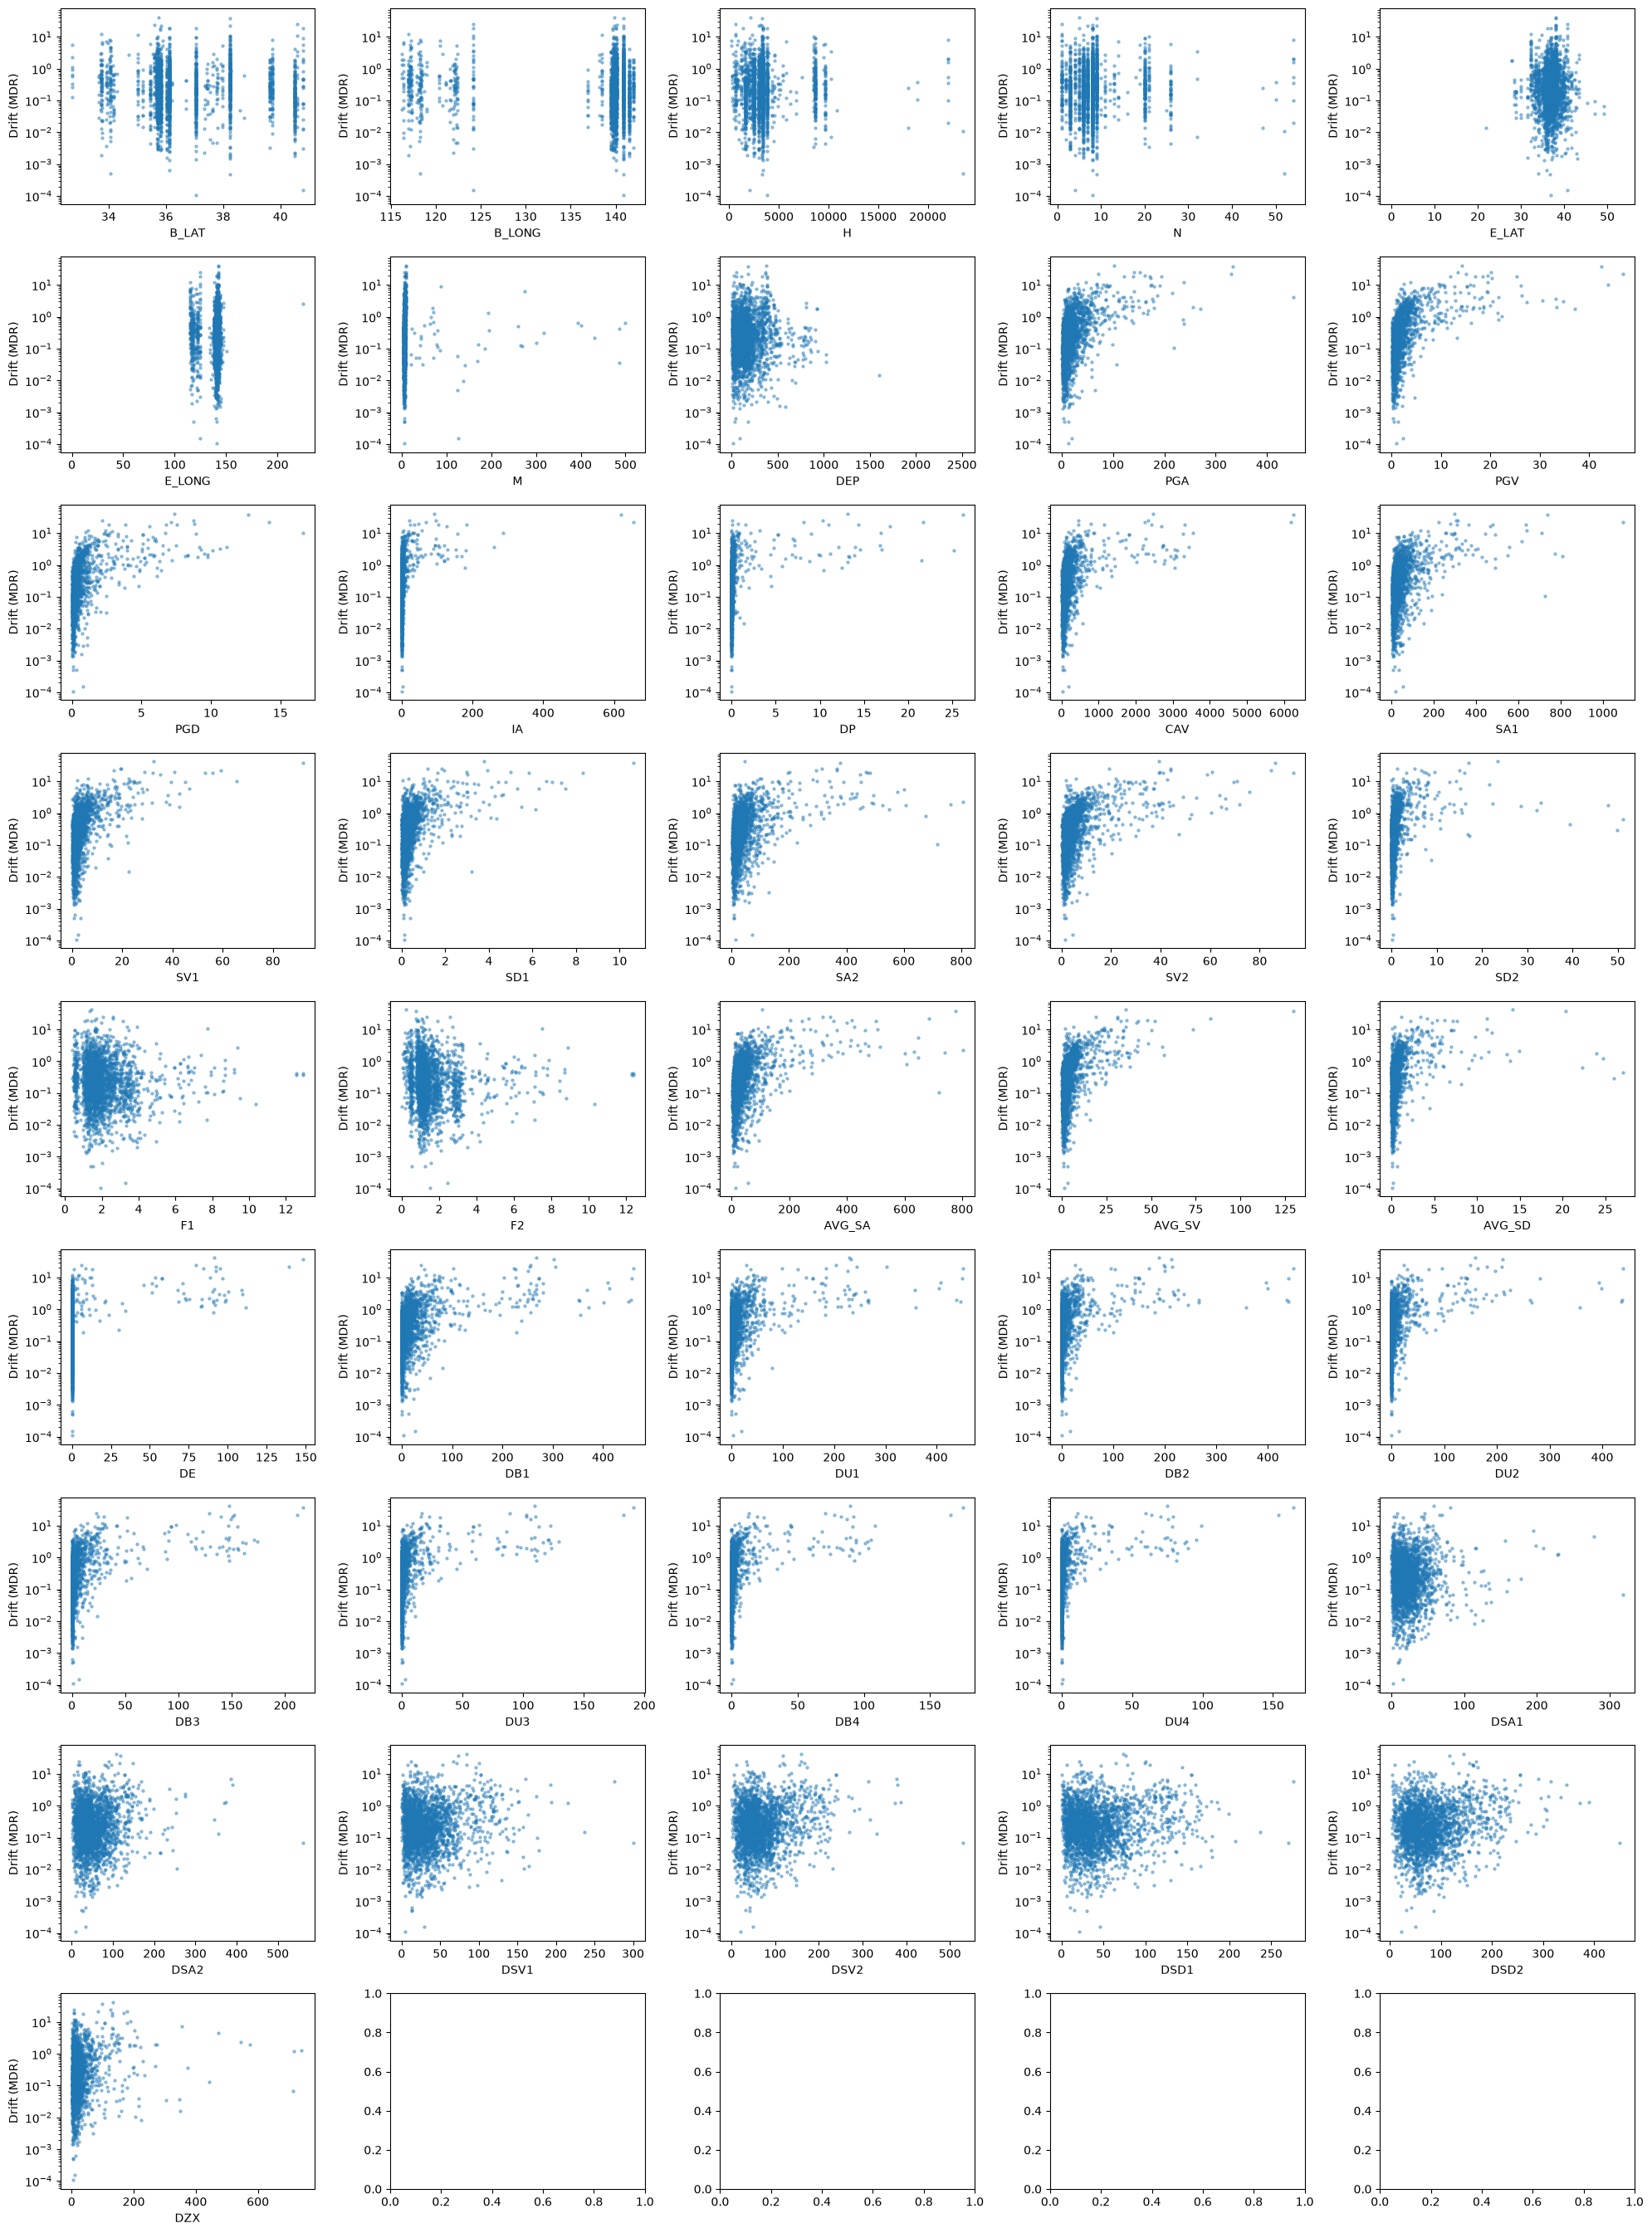

In [8]:
# scatterplot of Drift vs each feature

n_features = len(X_SVR.columns)
n_cols = 5
n_rows = -(-n_features // n_cols)  # ceiling division to determine number of rows needed for subplots

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(X_SVR.columns):
    axes[i].scatter(X_SVR[col], y, s=5, alpha=0.4)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Drift (MDR)")
    axes[i].set_yscale("log") #y-scale for drift

plt.tight_layout()
plt.show()

c. Highlight any particular pattern you observe from the visualizations. Which input features seem potentially more influential in predicting Drift?

YOUR TEXT HERE

## 3. Fit and evaluate (30 points)

a. Fit and evaluate a predictive framework using an SVR model. The process should include automatic tuning of both the kernel and the penalty parameter ((C)). Tune the hyperparameters using cross-validation on the training set, and evaluate the final predictive framework on a separate reporting set. Evaluate its performance using at least the Coefficient of Determination ($R^2$) and Mean Squared Error (MSE).

*N.B.* Remember that a predictive framework may involve more than just the predictive algorithm itself. Consider whether the characteristics of the predictors require any additional steps before fitting the model.

In [9]:
# split data
X_train, X_test, y_train, y_test = train_test_split(X_SVR, y, test_size=0.2, random_state=42)

In [10]:
# inner fold with best params
cv_inner = KFold(n_splits=5, shuffle=True, random_state=42)

# Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

# param grid for SVR -- we need to tune C and the kernel type
param_grid = {
    'svr__C': [0.1, 1, 10, 100],
    'svr__kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
}

# Grid search with inner cross-validation
SVR_grid_search = GridSearchCV(estimator=pipeline, 
                               param_grid=param_grid, 
                               cv=cv_inner, 
                               scoring='r2', 
                               n_jobs=10,
                               verbose=1)
SVR_grid_search.fit(X_train, y_train)

# Best parameters and score
svr_best_params = SVR_grid_search.best_params_
svr_mean_r2_score = SVR_grid_search.best_score_
svr_best_training_r2 = SVR_grid_search.score(X_train, y_train)
svr_best_test_r2 = SVR_grid_search.score(X_test, y_test)
svr_best_mse = mean_squared_error(y_test, SVR_grid_search.predict(X_test))


print("Best Parameters:", svr_best_params)
print("Mean CV R2 Score:", svr_mean_r2_score)
print("Best Training R2:", svr_best_training_r2)
print("Best Test R2:", svr_best_test_r2)
print("Best Test MSE:", svr_best_mse)


Fitting 5 folds for each of 16 candidates, totalling 80 fits


Best Parameters: {'svr__C': 0.1, 'svr__kernel': 'linear'}
Mean CV R2 Score: 0.41676678997622396
Best Training R2: 0.4648403376308956
Best Test R2: 0.5595861661974566
Best Test MSE: 0.3461065546359217


b. Repeat the previous process using an Ridge regression predictive framework. Be sure to include automatic tuning of the model's hyperparameters, specifically, `alpha`.

In [11]:
# alr fire now same thing with Ridge regression

ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

ridge_param_grid = {
    'ridge__alpha': [0.1, 1, 10, 100]
}

ridge_grid_search = GridSearchCV(estimator=ridge_pipeline,
                                 param_grid=ridge_param_grid,
                                 cv=cv_inner,
                                 scoring='r2',
                                 n_jobs=10,
                                 verbose=1)
ridge_grid_search.fit(X_train, y_train)

ridge_best_params = ridge_grid_search.best_params_
ridge_mean_r2_score = ridge_grid_search.best_score_
ridge_best_training_r2 = ridge_grid_search.score(X_train, y_train)
ridge_best_test_r2 = ridge_grid_search.score(X_test, y_test)
ridge_best_mse = mean_squared_error(y_test, ridge_grid_search.predict(X_test))

print("Best Parameters:", ridge_best_params)
print("Mean CV R2 Score:", ridge_mean_r2_score)
print("Best Training R2:", ridge_best_training_r2)
print("Best Test R2:", ridge_best_test_r2)
print("Best Test MSE:", ridge_best_mse)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Parameters: {'ridge__alpha': 100}
Mean CV R2 Score: 0.31045763725765846
Best Training R2: 0.5446011101785506
Best Test R2: 0.6094211847887746
Best Test MSE: 0.30694287434019485


c. Use predicted vs. true value scatterplots to compare the SVR and Ridge predictive frameworks. Embed performance metrics (e.g., R², MSE) in each plot.

Which predictive framework appears to perform better at this task?

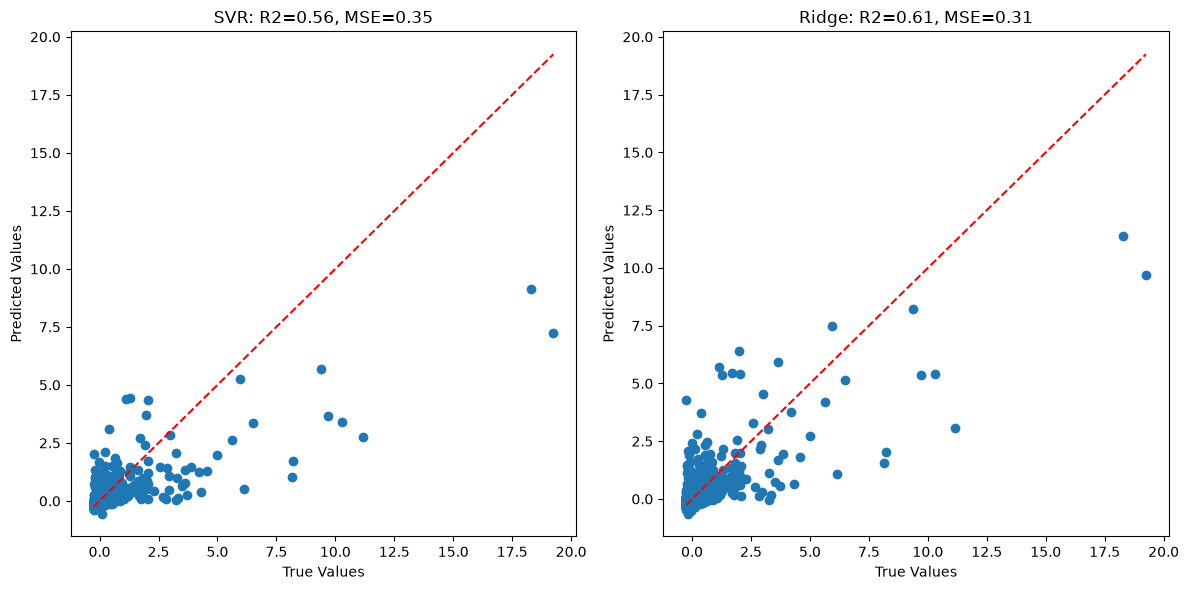

In [12]:
# [Your code here]
# actual vs. true plots for SVR and ridge regression. Embed R2 and MSE for both
# as in, a predictive line through the scatter plot
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
y_pred_svr = SVR_grid_search.predict(X_test)
plt.scatter(y_test, y_pred_svr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # predictive line
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"SVR: R2={SVR_grid_search.score(X_test, y_test):.2f}, MSE={mean_squared_error(y_test, y_pred_svr):.2f}")

plt.subplot(1, 2, 2)
y_pred_ridge = ridge_grid_search.predict(X_test)
plt.scatter(y_test, y_pred_ridge)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # predictive line
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"Ridge: R2={ridge_grid_search.score(X_test, y_test):.2f}, MSE={mean_squared_error(y_test, y_pred_ridge):.2f}")

plt.tight_layout()
plt.show()

## 4. Reduced SVR Model (30 points)

a. Add a feature selection step to the SVR predictive framework that selects the 10 features most highly correlated with Drift. Retrain  this updated framework and evaluate its performance.

In [13]:
# [Your code here]
cols_high_corr = ['H', 'N', 'F1', 'PGV', 'PGD', 'DEP', 'M', 'SA1', 'SV1', 'SD1']
X_RSVR = X_SVR[cols_high_corr]
y_rsvr = y[X_RSVR.index]

# split data for RSVR model
X_train_RSVR, X_test_RSVR, y_train_RSVR, y_test_RSVR = train_test_split(X_RSVR, y_rsvr, test_size=0.2, random_state=42)

# defining inner cross-validation for RSVR model
cv_inner_rsvr = KFold(n_splits=5, shuffle=True, random_state=42)

# rsvr pipeline
RSVR_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

# defining grid search for RSVR model
rsvr_param_grid = {
    'svr__C': [0.1, 1, 10, 100],
    'svr__kernel': ['linear', 'poly', 'rbf', 'sigmoid']
}

grid_search_RSVR = GridSearchCV(estimator=RSVR_pipeline, 
                                param_grid=rsvr_param_grid, 
                                cv=cv_inner_rsvr, 
                                scoring='r2', 
                                n_jobs=-1,
                                verbose=1)

grid_search_RSVR.fit(X_train_RSVR, y_train_RSVR)

rsvr_best_params = grid_search_RSVR.best_params_
rsvr_mean_r2_score = grid_search_RSVR.best_score_
rsvr_best_training_r2 = grid_search_RSVR.score(X_train_RSVR, y_train_RSVR)
rsvr_best_test_r2 = grid_search_RSVR.score(X_test_RSVR, y_test_RSVR)
rsvr_best_mse = mean_squared_error(y_test_RSVR, grid_search_RSVR.predict(X_test_RSVR))

print("Best Parameters:", rsvr_best_params)
print("Mean CV R2 Score:", rsvr_mean_r2_score)
print("Best Training R2:", rsvr_best_training_r2)
print("Best Test R2:", rsvr_best_test_r2)
print("Best Test MSE:", rsvr_best_mse)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'svr__C': 100, 'svr__kernel': 'rbf'}
Mean CV R2 Score: 0.40503381280065975
Best Training R2: 0.9529678007400917
Best Test R2: 0.3244916397271773
Best Test MSE: 0.5308595081656978


Subsequently, answer the following questions:

- How much does the performance change?
- What are the practical advantages of using this predictive framework with a smaller subset of features?

Elaborate on your answers.

b. Compare the performance of this reduced-feature SVR framework with an optimal Lasso regression framework that uses all available features.

- Do both frameworks select the same features?
- How do their performances compare?

In [14]:
# [Your code here]

## 5: Robustness to Point Removal (10 points)

a. Compare the sensitivity of SVR and Ridge Regression predictive frameworks to small changes in the training set. To achieve this, randomly remove 10 training points, retrain both predictive frameworks, and assess how much the predictions change.

- Which predictive frameworks appears more stable?
- Why?

In [15]:
# [Your code here]

## 6. Collaboration Reflection (5 points)

As a group, identify **one specific challenge or inefficiency** you encountered while working on this lab. In 3–5 sentences:

1. Briefly describe what happened and how it affected your work.
2. Identify one concrete action your group will take to avoid or better manage this issue in the next lab.

If your group encountered no major problem, identify one aspect of your collaboration that could still be improved.

YOUR TEXT HERE